# Random Number Generation

In this notebook we will explore random number generation with numpy, including generation of probability distributions using two methods. First we set up the random number generator.


In [1]:
import numpy as np
rng = np.random.default_rng()

Then generate a random (floating point) number between 0 and 1.  Try running the cell below several times to see the sequence.

In [4]:
rng.random()

0.21019249785564154

Now see what happens if we set a random seed.  The cell below should give the same output every time you run it, because it resets the random seed.

In [11]:
rng = np.random.default_rng(1234)
rng.random(5)

array([0.97669977, 0.38019574, 0.92324623, 0.26169242, 0.31909706])

## Random distributions - inverse method

Suppose we want to generate random numbers between 0 and $\pi$ according to a PDF : 
$$P(x) = sin(x)$$

We want to transform numbers $x_{gen}$ produced with `rng.random()` into numbers distributed with the required PDF, $x_{req}$.  We can use the analytic inverse method to identify such a transformation.

$$\frac{1}{2} \int_{0}^{x_{req}} {\rm sin}(x) dx = \int_{0}^{x_{gen}} dx = x_{gen}$$

Note the factor 1/2, which is included to ensure the LH integral has unit area over the desired range of $x_{req}$, ie. 0 to $\pi$.  Failing to include this will produced $x_{req}$ only up to $\pi/2$.

Then we have :
    $$-{\rm cos}(x_{req}) + 1 = 2 x_{gen}$$
    
Hence :
    $$x_{req} = {\rm cos}^{-1}(1 - 2 x_{gen})$$

This is implemented easily in the cell below.

In [13]:
x_gen = rng.random(10000)
x_req = np.arccos(1-2*x_gen)

Now we can make a histogram of the results and check that it has the required distribution

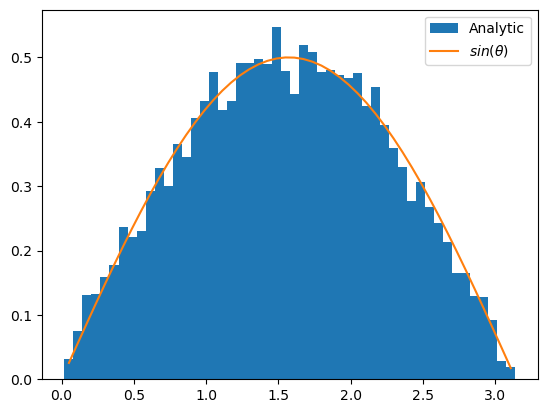

In [14]:
import matplotlib.pyplot as plt

# plot a histogram of the results
hist, bins, patches = plt.hist(x_req, bins=50, density=True, label="Analytic")

# find the histogram bin centres
bin_centres = (bins[1:] + bins[:-1])/2

# plot a sin function based on bin centres
plt.plot(bin_centres, np.sin(bin_centres)/2, label=r'$sin(\theta)$')

plt.legend()
plt.show()

In the above cell, we just plotted the desired PDF based on the value of the histogram bin centres. A more sophisticated analysis might be to fit the desired function to the pseudo-random data.  You can try increasing the number of point generated to see if the results do get closer to the desired distribution.

## Random distributions - inverse method

Sometimes we will want to produce a distribution which cannot be inverted.  Or even to sample from a distribution that has been measured in data.  In such cases, the accept reject method can be used.  This is implemented for the same $sin(x)$ example in the cell below.

In [15]:
x = np.pi * rng.random(10000)
y = rng.random(10000)

# select only elements of x which satisfy the accept/reject condition, using boolean array indexing
x_req = x[ y < np.sin(x) ]

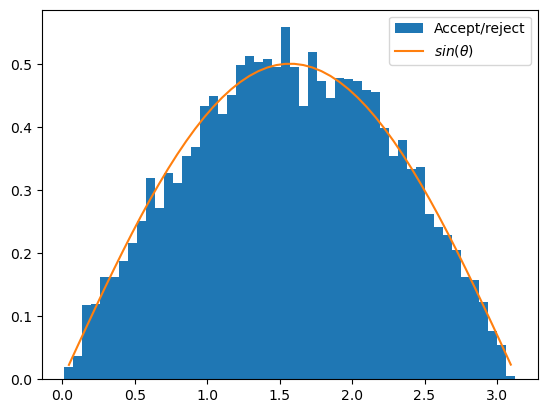

In [16]:
# plot a histogram of the results
hist, bins, patches = plt.hist(x_req, bins=50, density=True, label="Accept/reject")

# find the histogram bin centres
bin_centres = (bins[1:] + bins[:-1])/2

# plot a sin function based on bin centres
plt.plot(bin_centres, np.sin(bin_centres)/2, label=r'$sin(\theta)$')

plt.legend()
plt.show()